# Logistic Regression

Binary classification on California housing: predict whether median house value is above the median.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)

data_df = pd.read_csv("housing.csv")
data_df['total_bedrooms'] = data_df['total_bedrooms'].fillna(data_df['total_bedrooms'].median())
data_df = pd.get_dummies(data_df, columns=['ocean_proximity'], dtype=float)

threshold = data_df['median_house_value'].median()
y = (data_df['median_house_value'] > threshold).astype(int).to_numpy()
X = data_df.drop(columns=['median_house_value']).to_numpy()
feature_names = list(data_df.drop(columns=['median_house_value']).columns)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, shuffle=True, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(np.bincount(y_train), np.bincount(y_test))

(13828, 13) (6812, 13)
[6916 6912] [3407 3405]


## Baseline

In [2]:
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Below', 'Above']))

Accuracy: 0.8437
[[2885  522]
 [ 543 2862]]
              precision    recall  f1-score   support

       Below       0.84      0.85      0.84      3407
       Above       0.85      0.84      0.84      3405

    accuracy                           0.84      6812
   macro avg       0.84      0.84      0.84      6812
weighted avg       0.84      0.84      0.84      6812



## Regularization sweep

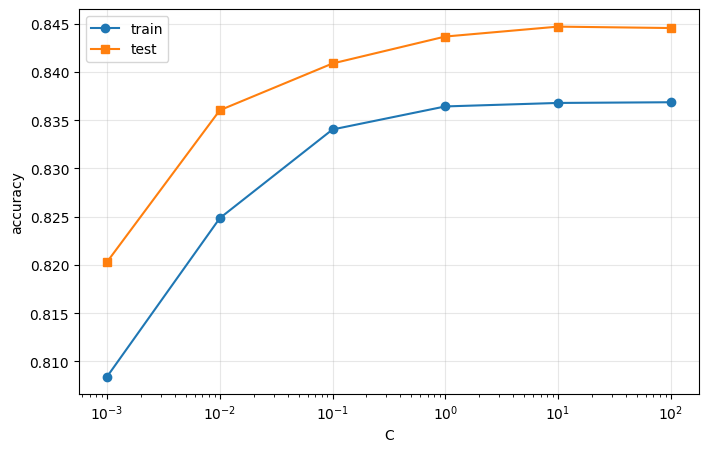

C=0.001  train=0.8084 test=0.8203
C=0.01   train=0.8248 test=0.8360
C=0.1    train=0.8340 test=0.8409
C=1      train=0.8364 test=0.8437
C=10     train=0.8368 test=0.8447
C=100    train=0.8369 test=0.8445


In [3]:
Cs = [0.001, 0.01, 0.1, 1, 10, 100]
train_acc, test_acc = [], []

for C in Cs:
    m = LogisticRegression(C=C, max_iter=2000, random_state=42)
    m.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.semilogx(Cs, train_acc, 'o-', label='train')
plt.semilogx(Cs, test_acc, 's-', label='test')
plt.xlabel('C')
plt.ylabel('accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for C, tr, te in zip(Cs, train_acc, test_acc):
    print(f"C={C:<6} train={tr:.4f} test={te:.4f}")

## From-scratch logistic regression (gradient descent)

Scratch train acc: 0.8204
Scratch test acc:  0.8291


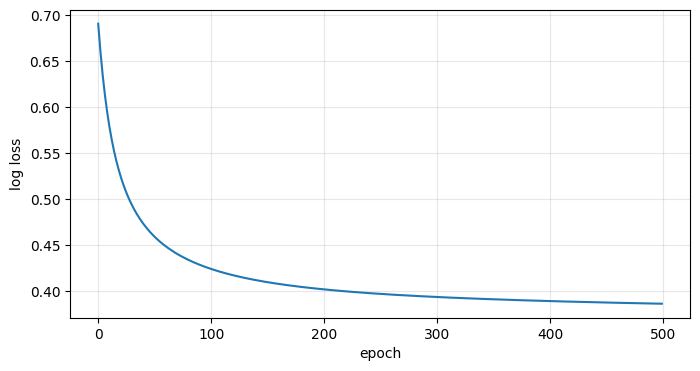

In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

class LogRegScratch:
    def __init__(self, lr=0.1, epochs=500, seed=42):
        self.lr = lr
        self.epochs = epochs
        self.seed = seed

    def fit(self, X, y):
        rng = np.random.default_rng(self.seed)
        n, d = X.shape
        self.w = rng.normal(0, 0.01, size=d)
        self.b = 0.0
        self.loss_ = []
        for _ in range(self.epochs):
            z = X @ self.w + self.b
            p = sigmoid(z)
            loss = -np.mean(y * np.log(p + 1e-12) + (1 - y) * np.log(1 - p + 1e-12))
            self.loss_.append(loss)
            grad_w = X.T @ (p - y) / n
            grad_b = np.mean(p - y)
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b
        return self

    def predict_proba(self, X):
        return sigmoid(X @ self.w + self.b)

    def predict(self, X, t=0.5):
        return (self.predict_proba(X) >= t).astype(int)

scratch = LogRegScratch(lr=0.1, epochs=500).fit(X_train, y_train)
print(f"Scratch train acc: {accuracy_score(y_train, scratch.predict(X_train)):.4f}")
print(f"Scratch test acc:  {accuracy_score(y_test, scratch.predict(X_test)):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(scratch.loss_)
plt.xlabel('epoch')
plt.ylabel('log loss')
plt.grid(alpha=0.3)
plt.show()

## ROC curve and threshold sweep

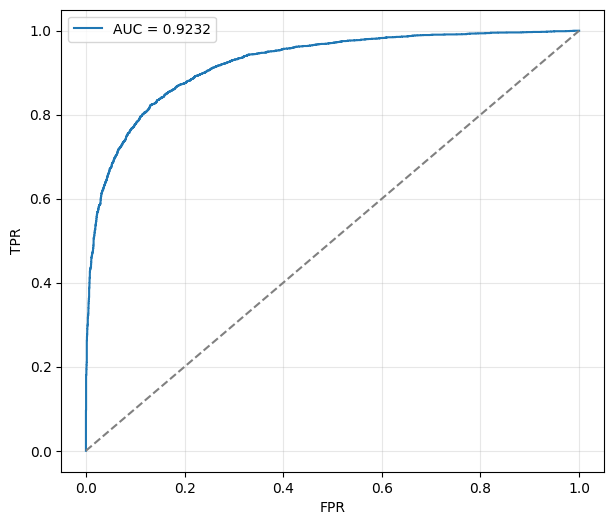

t=0.10  acc=0.7130
t=0.20  acc=0.7820
t=0.30  acc=0.8172
t=0.40  acc=0.8343
t=0.50  acc=0.8437
t=0.60  acc=0.8397
t=0.70  acc=0.8256
t=0.80  acc=0.7890
t=0.90  acc=0.7149


In [5]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

thresholds = np.linspace(0.1, 0.9, 9)
for t in thresholds:
    preds = (y_proba >= t).astype(int)
    print(f"t={t:.2f}  acc={accuracy_score(y_test, preds):.4f}")

## Top coefficients

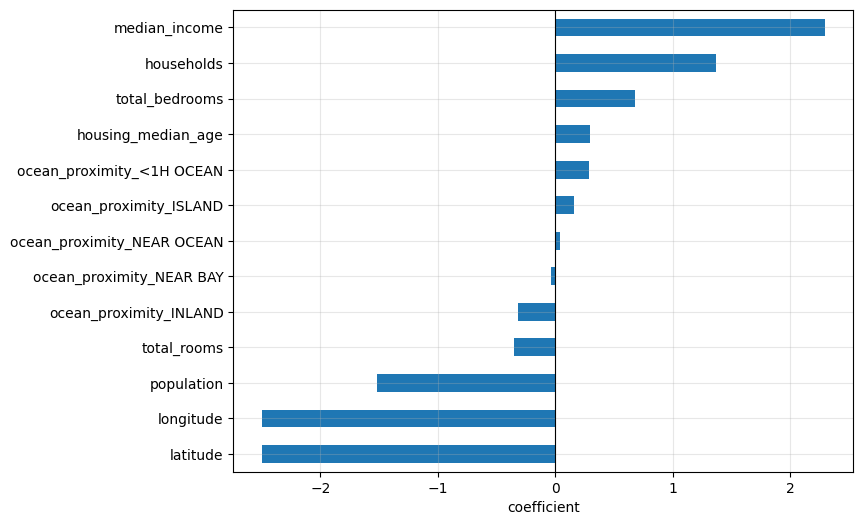

latitude                     -2.501673
longitude                    -2.494753
population                   -1.518641
total_rooms                  -0.350877
ocean_proximity_INLAND       -0.315778
ocean_proximity_NEAR BAY     -0.038772
ocean_proximity_NEAR OCEAN    0.040022
ocean_proximity_ISLAND        0.154270
ocean_proximity_<1H OCEAN     0.288613
housing_median_age            0.291950
total_bedrooms                0.674358
households                    1.365626
median_income                 2.295958
dtype: float64


In [6]:
coefs = pd.Series(clf.coef_[0], index=feature_names).sort_values()

plt.figure(figsize=(8, 6))
coefs.plot(kind='barh')
plt.axvline(0, color='k', lw=0.8)
plt.xlabel('coefficient')
plt.grid(alpha=0.3)
plt.show()

print(coefs)